In [1]:
import os
import glob
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Path folder
folder_path = r'C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet'

# Cek semua file di folder
print("Files in folder:")
all_files = os.listdir(folder_path)
for file in all_files:
    print(f"  - {file}")

# Cari file .mat
mat_files = glob.glob(os.path.join(folder_path, "*.mat"))
print(f"\nFile .mat ditemukan: {len(mat_files)}")
for mat_file in mat_files:
    print(f"  - {os.path.basename(mat_file)}")

Files in folder:
  - EEG_all_epochs.mat
  - EEG_all_epochs.npy
  - EMG_all_epochs.mat
  - EMG_all_epochs.npy
  - EOG_all_epochs.mat
  - EOG_all_epochs.npy

File .mat ditemukan: 3
  - EEG_all_epochs.mat
  - EMG_all_epochs.mat
  - EOG_all_epochs.mat


In [3]:
# Jika masih ragu, bisa cek dengan cara ini:
if len(mat_files) > 0:
    mat_path = mat_files[0]
    data = scipy.io.loadmat(mat_path)
    
    # Cari key yang berisi data numerik
    for key in data.keys():
        if not key.startswith('__'):
            value = data[key]
            if isinstance(value, np.ndarray) and value.ndim >= 2:
                print(f"\nData pada key '{key}':")
                print(f"Shape: {value.shape}")
                
                # Tampilkan informasi statistik per channel
                if value.ndim == 2:
                    # Asumsi format (channel, samples)
                    if value.shape[0] < value.shape[1]:
                        n_channels = value.shape[0]
                        print(f"Jumlah channel: {n_channels}")
                        print(f"Panjang sinyal per channel: {value.shape[1]} samples")
                    else:
                        n_channels = value.shape[1]
                        print(f"Jumlah channel: {n_channels}")
                        print(f"Panjang sinyal per channel: {value.shape[0]} samples")


Data pada key 'EEG_all_epochs':
Shape: (4514, 512)
Jumlah channel: 512
Panjang sinyal per channel: 4514 samples

Data pada key 'fs':
Shape: (1, 1)
Jumlah channel: 1
Panjang sinyal per channel: 1 samples


In [6]:
import pyedflib
import os
import numpy as np
import glob

def analyze_edf_file(edf_path):
    """Menganalisis file EDF untuk mengetahui informasi channel"""
    try:
        # Baca file EDF
        with pyedflib.EdfReader(edf_path) as f:
            # Dapatkan informasi header
            n_channels = f.signals_in_file
            channel_labels = f.getSignalLabels()
            n_samples = f.getNSamples()[0]  # samples per channel
            duration = f.getFileDuration()
            sampling_freq = f.getSampleFrequency(0)
            
            print(f"=== ANALISIS FILE: {os.path.basename(edf_path)} ===")
            print(f"Jumlah channel: {n_channels}")
            print(f"Frekuensi sampling: {sampling_freq} Hz")
            print(f"Durasi recording: {duration} detik")
            print(f"Samples per channel: {n_samples}")
            print(f"\nDaftar channel:")
            
            for i, label in enumerate(channel_labels):
                print(f"  {i+1:2d}. {label}")
            
            # Baca data sinyal (opsional, untuk verifikasi)
            signals = np.zeros((n_channels, n_samples))
            for i in range(n_channels):
                signals[i, :] = f.readSignal(i)
            
            print(f"\nBentuk data EEG: {signals.shape}")
            print(f"Format: {signals.shape[0]} channel x {signals.shape[1]} samples")
            
            return signals, channel_labels, sampling_freq
            
    except Exception as e:
        print(f"Error membaca file {edf_path}: {str(e)}")
        return None, None, None

def analyze_edf_event(event_path):
    """Menganalisis file event"""
    try:
        with open(event_path, 'r') as f:
            events = f.readlines()
        
        print(f"\n=== EVENT DATA: {os.path.basename(event_path)} ===")
        print(f"Jumlah event: {len(events)}")
        for i, event in enumerate(events[:10]):  # Tampilkan 10 event pertama
            print(f"  Event {i+1}: {event.strip()}")
        if len(events) > 10:
            print(f"  ... dan {len(events)-10} event lainnya")
            
    except Exception as e:
        print(f"Error membaca event file: {str(e)}")

def analyze_all_edf_files(directory="."):
    """Analisis semua file EDF dalam direktori"""
    # Ganti ke directory yang sesuai
    os.chdir(directory)
    
    edf_files = glob.glob("*.edf")
    edf_files = [f for f in edf_files if not f.endswith('.event')]
    
    print(f"Ditemukan {len(edf_files)} file EDF:")
    
    for edf_file in edf_files:
        print(f"\n{'='*60}")
        # Gunakan fungsi analyze_edf_file, bukan analyze_edf_with_mne
        eeg_data, channels, fs = analyze_edf_file(edf_file)
        
        # Cek file event yang sesuai
        event_file = edf_file + ".event"
        if os.path.exists(event_file):
            analyze_edf_event(event_file)

# Contoh penggunaan untuk single file
if __name__ == "__main__":
    # Path ke dataset Anda
    dataset_path = r"C:\Users\akip\Desktop\EEGdenoiseNet\eeg-motor-movementimagery-dataset-1.0.0"
    
    # Coba analisis satu file dulu
    test_file = os.path.join(dataset_path, "S001", "S001R01.edf")
    
    if os.path.exists(test_file):
        print("Menganalisis file tunggal...")
        eeg_data, channels, fs = analyze_edf_file(test_file)
        
        if eeg_data is not None:
            print(f"\n=== INFORMASI TAMBAHAN ===")
            print(f"Range data channel 1: {eeg_data[0].min():.2f} hingga {eeg_data[0].max():.2f}")
            print(f"5 sample pertama channel 1: {eeg_data[0][:5]}")
    else:
        print(f"File {test_file} tidak ditemukan!")
        print("Mencari struktur folder...")
        
        # Analisis struktur folder
        analyze_dataset_structure(dataset_path)

def analyze_dataset_structure(directory):
    """Analisis struktur dataset"""
    print(f"\nAnalisis struktur dataset di: {directory}")
    
    # Cari semua folder subject
    subjects = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d)) and d.startswith('S')]
    print(f"Ditemukan {len(subjects)} subjects: {subjects}")
    
    if subjects:
        # Analisis subject pertama
        first_subject = os.path.join(directory, subjects[0])
        print(f"\nAnalisis files di {first_subject}:")
        
        edf_files = glob.glob(os.path.join(first_subject, "*.edf"))
        edf_files = [f for f in edf_files if not f.endswith('.event')]
        
        for edf_file in edf_files[:2]:  # Analisis 2 file pertama saja
            print(f"\n{'='*60}")
            eeg_data, channels, fs = analyze_edf_file(edf_file)
            
            # Cek file event
            event_file = edf_file + ".event"
            if os.path.exists(event_file):
                analyze_edf_event(event_file)



Menganalisis file tunggal...
=== ANALISIS FILE: S001R01.edf ===
Jumlah channel: 64
Frekuensi sampling: 160.0 Hz
Durasi recording: 61.0 detik
Samples per channel: 9760

Daftar channel:
   1. Fc5.
   2. Fc3.
   3. Fc1.
   4. Fcz.
   5. Fc2.
   6. Fc4.
   7. Fc6.
   8. C5..
   9. C3..
  10. C1..
  11. Cz..
  12. C2..
  13. C4..
  14. C6..
  15. Cp5.
  16. Cp3.
  17. Cp1.
  18. Cpz.
  19. Cp2.
  20. Cp4.
  21. Cp6.
  22. Fp1.
  23. Fpz.
  24. Fp2.
  25. Af7.
  26. Af3.
  27. Afz.
  28. Af4.
  29. Af8.
  30. F7..
  31. F5..
  32. F3..
  33. F1..
  34. Fz..
  35. F2..
  36. F4..
  37. F6..
  38. F8..
  39. Ft7.
  40. Ft8.
  41. T7..
  42. T8..
  43. T9..
  44. T10.
  45. Tp7.
  46. Tp8.
  47. P7..
  48. P5..
  49. P3..
  50. P1..
  51. Pz..
  52. P2..
  53. P4..
  54. P6..
  55. P8..
  56. Po7.
  57. Po3.
  58. Poz.
  59. Po4.
  60. Po8.
  61. O1..
  62. Oz..
  63. O2..
  64. Iz..

Bentuk data EEG: (64, 9760)
Format: 64 channel x 9760 samples

=== INFORMASI TAMBAHAN ===
Range data channel 1:

In [7]:
# Jalankan analisis
if __name__ == "__main__":
    dataset_path = r"C:\Users\akip\Desktop\EEGdenoiseNet\eeg-motor-movementimagery-dataset-1.0.0"
    
    if os.path.exists(dataset_path):
        print(f"Dataset ditemukan di: {dataset_path}")
        analyze_dataset_structure(dataset_path)
    else:
        print(f"Path {dataset_path} tidak ditemukan!")
        # Coba path alternatif
        current_dir = os.getcwd()
        print(f"Current directory: {current_dir}")
        print(f"Files in current directory: {os.listdir('.')}")

Dataset ditemukan di: C:\Users\akip\Desktop\EEGdenoiseNet\eeg-motor-movementimagery-dataset-1.0.0

Analisis struktur dataset di: C:\Users\akip\Desktop\EEGdenoiseNet\eeg-motor-movementimagery-dataset-1.0.0
Ditemukan 17 subjects: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010', 'S011', 'S012', 'S013', 'S014', 'S015', 'S016', 'S017']

Analisis files di C:\Users\akip\Desktop\EEGdenoiseNet\eeg-motor-movementimagery-dataset-1.0.0\S001:

=== ANALISIS FILE: S001R01.edf ===
Jumlah channel: 64
Frekuensi sampling: 160.0 Hz
Durasi recording: 61.0 detik
Samples per channel: 9760

Daftar channel:
   1. Fc5.
   2. Fc3.
   3. Fc1.
   4. Fcz.
   5. Fc2.
   6. Fc4.
   7. Fc6.
   8. C5..
   9. C3..
  10. C1..
  11. Cz..
  12. C2..
  13. C4..
  14. C6..
  15. Cp5.
  16. Cp3.
  17. Cp1.
  18. Cpz.
  19. Cp2.
  20. Cp4.
  21. Cp6.
  22. Fp1.
  23. Fpz.
  24. Fp2.
  25. Af7.
  26. Af3.
  27. Afz.
  28. Af4.
  29. Af8.
  30. F7..
  31. F5..
  32. F3..
  33. F1..
  34. Fz..
  35

In [1]:
import mne
import os
import numpy as np
import glob
import matplotlib.pyplot as plt

def analyze_gdf_file(gdf_path):
    """Menganalisis file GDF untuk mengetahui informasi channel"""
    try:
        # Baca file GDF dengan MNE
        raw = mne.io.read_raw_gdf(gdf_path, preload=True)
        
        print(f"=== ANALISIS FILE: {os.path.basename(gdf_path)} ===")
        print(f"Jumlah channel: {len(raw.ch_names)}")
        print(f"Frekuensi sampling: {raw.info['sfreq']} Hz")
        print(f"Durasi: {raw.times[-1]:.2f} detik")
        print(f"Bentuk data: {raw.get_data().shape}")
        
        # Informasi channel
        print(f"\nDaftar channel:")
        for i, ch_name in enumerate(raw.ch_names):
            ch_type = raw.get_channel_types()[i]
            print(f"  {i+1:2d}. {ch_name} ({ch_type})")
        
        # Informasi events
        events, event_ids = mne.events_from_annotations(raw)
        print(f"\nJumlah events: {len(events)}")
        print(f"Event IDs: {event_ids}")
        
        if len(events) > 0:
            print("10 event pertama:")
            for i in range(min(10, len(events))):
                print(f"  Sample: {events[i, 0]}, Event ID: {events[i, 2]}")
        
        # Informasi statistik
        data = raw.get_data()
        print(f"\nINFORMASI STATISTIK:")
        print(f"Bentuk data: {data.shape} (channels x samples)")
        print(f"Range data seluruh channel: {data.min():.2f} hingga {data.max():.2f}")
        
        # Tampilkan beberapa sample dari channel pertama
        print(f"\n5 sample pertama channel 1 ({raw.ch_names[0]}):")
        print(data[0, :5])
        
        return raw, events, event_ids
        
    except Exception as e:
        print(f"Error membaca file {gdf_path}: {str(e)}")
        return None, None, None

def bci_competition_analysis(directory):
    """Analisis khusus untuk dataset BCI Competition IV dataset2"""
    print("BCI COMPETITION IV - DATASET 2 ANALYSIS")
    print("=" * 60)
    
    # Ganti ke directory yang dituju
    os.chdir(directory)
    
    # Cari file GDF
    gdf_files = glob.glob("*.gdf")
    gdf_files.sort()
    
    print(f"Directory: {directory}")
    print(f"Total GDF files found: {len(gdf_files)}")
    print(f"Files: {gdf_files}")
    
    if not gdf_files:
        print("Tidak ada file GDF ditemukan!")
        print(f"Files in directory: {os.listdir(directory)}")
        return
    
    summary = {}
    for gdf_file in gdf_files:
        filename = os.path.basename(gdf_file)
        print(f"\n{'='*80}")
        print(f"ANALYZING: {filename}")
        
        raw, events, event_ids = analyze_gdf_file(gdf_file)
        
        if raw is not None:
            # Extract subject and type from filename
            subject = filename[:3]  # A01, A02, etc.
            data_type = "Evaluation" if "E" in filename else "Training"
            
            summary[filename] = {
                'subject': subject,
                'type': data_type,
                'n_channels': len(raw.ch_names),
                'sfreq': raw.info['sfreq'],
                'duration': raw.times[-1],
                'n_events': len(events),
                'event_types': list(event_ids.keys()),
                'channel_names': raw.ch_names
            }
    
    # Print summary
    print(f"\n{'='*100}")
    print("SUMMARY - BCI COMPETITION IV DATASET 2")
    print("=" * 100)
    print(f"{'File':<10} {'Subject':<8} {'Type':<12} {'Channels':<10} {'Sampling':<10} {'Duration':<10} {'Events':<8} {'Event Types'}")
    print("-" * 100)
    
    for filename, info in summary.items():
        event_types_str = str(info['event_types'])[:30] + "..." if len(str(info['event_types'])) > 30 else str(info['event_types'])
        print(f"{filename:<10} {info['subject']:<8} {info['type']:<12} {info['n_channels']:<10} {info['sfreq']:<10} {info['duration']:<10.1f} {info['n_events']:<8} {event_types_str}")

def quick_gdf_check(directory):
    """Quick check untuk file GDF"""
    print("\n🚀 QUICK CHECK - BCI COMPETITION IV DATASET 2")
    print("=" * 50)
    
    os.chdir(directory)
    gdf_files = glob.glob("*.gdf")
    gdf_files.sort()
    
    if not gdf_files:
        print("❌ Tidak ada file GDF ditemukan!")
        return
    
    for gdf_file in gdf_files:
        print(f"\n📊 {gdf_file}:")
        try:
            # Gunakan preload=False untuk lebih cepat
            raw = mne.io.read_raw_gdf(gdf_file, preload=False)
            events, event_ids = mne.events_from_annotations(raw)
            
            print(f"   ✅ Channels: {len(raw.ch_names)}")
            print(f"   ✅ Sampling: {raw.info['sfreq']} Hz")
            print(f"   ✅ Duration: {raw.times[-1]:.1f}s")
            print(f"   ✅ Events: {len(events)}")
            print(f"   ✅ Event types: {list(event_ids.keys())}")
            
            # Tampilkan channel EEG saja (biasanya dimulai dengan EEG)
            eeg_channels = [ch for ch in raw.ch_names if 'EEG' in ch or 'eeg' in ch.lower()]
            if eeg_channels:
                print(f"   ✅ EEG channels: {len(eeg_channels)}")
                print(f"   ✅ First 5 EEG: {eeg_channels[:5]}")
            else:
                print(f"   ✅ First 5 channels: {raw.ch_names[:5]}")
            
        except Exception as e:
            print(f"   ❌ ERROR: {str(e)}")

def visualize_first_file(directory):
    """Visualisasi file pertama untuk inspeksi visual"""
    os.chdir(directory)
    gdf_files = glob.glob("*.gdf")
    
    if gdf_files:
        first_file = gdf_files[0]
        print(f"\n👁️ VISUALISASI: {first_file}")
        
        try:
            raw = mne.io.read_raw_gdf(first_file, preload=True)
            
            # Plot 10 detik pertama, maksimal 16 channel
            n_channels = min(16, len(raw.ch_names))
            raw.plot(duration=10, n_channels=n_channels, 
                    title=f"Raw Data - {first_file}",
                    scalings='auto')
            
            # Plot events jika ada
            events, event_ids = mne.events_from_annotations(raw)
            if len(events) > 0:
                fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'])
                fig.suptitle(f"Events - {first_file}")
            
            plt.show()
            
        except Exception as e:
            print(f"Error dalam visualisasi: {str(e)}")



✅ Dataset ditemukan di: C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV\dataset2

🚀 QUICK CHECK - BCI COMPETITION IV DATASET 2

📊 A01E.gdf:
Extracting EDF parameters from C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV\dataset2\A01E.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


c:\python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '783']
   ✅ Channels: 25
   ✅ Sampling: 250.0 Hz
   ✅ Duration: 2748.0s
   ✅ Events: 595
   ✅ Event types: ['1023', '1072', '276', '277', '32766', '768', '783']
   ✅ EEG channels: 22
   ✅ First 5 EEG: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3']

📊 A01T.gdf:
Extracting EDF parameters from C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV\dataset2\A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
   ✅ Channels: 25
   ✅ Sampling: 250.0 Hz
   ✅ Duration: 2690.1s
   ✅ Events: 603
   ✅ Event types: ['1023', '1072', 

c:\python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
c:\python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
c:\python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
c:\python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
   ✅ Channels: 25
   ✅ Sampling: 250.0 Hz
   ✅ Duration: 2642.1s
   ✅ Events: 606
   ✅ Event types: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
   ✅ EEG channels: 22
   ✅ First 5 EEG: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3']

📊 A04E.gdf:
Extracting EDF parameters from C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV\dataset2\A04E.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG,

...

=== ANALISIS FILE: A09E.gdf ===
Jumlah channel: 25
Frekuensi sampling: 250.0 Hz
Durasi: 2700.39 detik
Bentuk data: (25, 675098)

Daftar channel:
   1. EEG-Fz (eeg)
   2. EEG-0 (eeg)
   3. EEG-1 (eeg)
   4. EEG-2 (eeg)
   5. EEG-3 (eeg)
   6. EEG-4 (eeg)
   7. EEG-5 (eeg)
   8. EEG-C3 (eeg)
   9. EEG-6 (eeg)
  10. EEG-Cz (eeg)
  11. EEG-7 (eeg)
  12. EEG-C4 (eeg)
  13. EEG-8 (eeg)
  14. EEG-9 (eeg)
  15. EEG-10 (eeg)
  16. EEG-11 (eeg)
  17. EEG-12 (eeg)
  18. EEG-13 (eeg)
  19. EEG-14 (eeg)
  20. EEG-Pz (eeg)
  21. EEG-15 (eeg)
  22. EEG-16 (eeg)
  23. EOG-left (eeg)
  24. EOG-central (eeg)
  25. EOG-right (eeg)
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '783']

Jumlah events: 612
Event IDs: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '783': 7}
10 event pertama:
  Sample: 0, Event ID: 5
  Sample: 0, Event ID: 3
  Sample: 25808, Event ID: 5
  Sample: 25808, Event ID: 4
  Sample: 52927, Event ID: 5
  Sample: 52927, Event ID: 2
  Sam

c:\python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


=== ANALISIS FILE: A09T.gdf ===
Jumlah channel: 25
Frekuensi sampling: 250.0 Hz
Durasi: 2693.31 detik
Bentuk data: (25, 673328)

Daftar channel:
   1. EEG-Fz (eeg)
   2. EEG-0 (eeg)
   3. EEG-1 (eeg)
   4. EEG-2 (eeg)
   5. EEG-3 (eeg)
   6. EEG-4 (eeg)
   7. EEG-5 (eeg)
   8. EEG-C3 (eeg)
   9. EEG-6 (eeg)
  10. EEG-Cz (eeg)
  11. EEG-7 (eeg)
  12. EEG-C4 (eeg)
  13. EEG-8 (eeg)
  14. EEG-9 (eeg)
  15. EEG-10 (eeg)
  16. EEG-11 (eeg)
  17. EEG-12 (eeg)
  18. EEG-13 (eeg)
  19. EEG-14 (eeg)
  20. EEG-Pz (eeg)
  21. EEG-15 (eeg)
  22. EEG-16 (eeg)
  23. EOG-left (eeg)
  24. EOG-central (eeg)
  25. EOG-right (eeg)
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']

Jumlah events: 639
Event IDs: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
10 event pertama:
  Sample: 0, Event ID: 5
  Sample: 0, Event ID: 3
  Sample: 30878, Event ID: 5
  Sample: 30878, Event ID: 4
  Sample: 5

c:\python\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Using matplotlib as 2D backend.


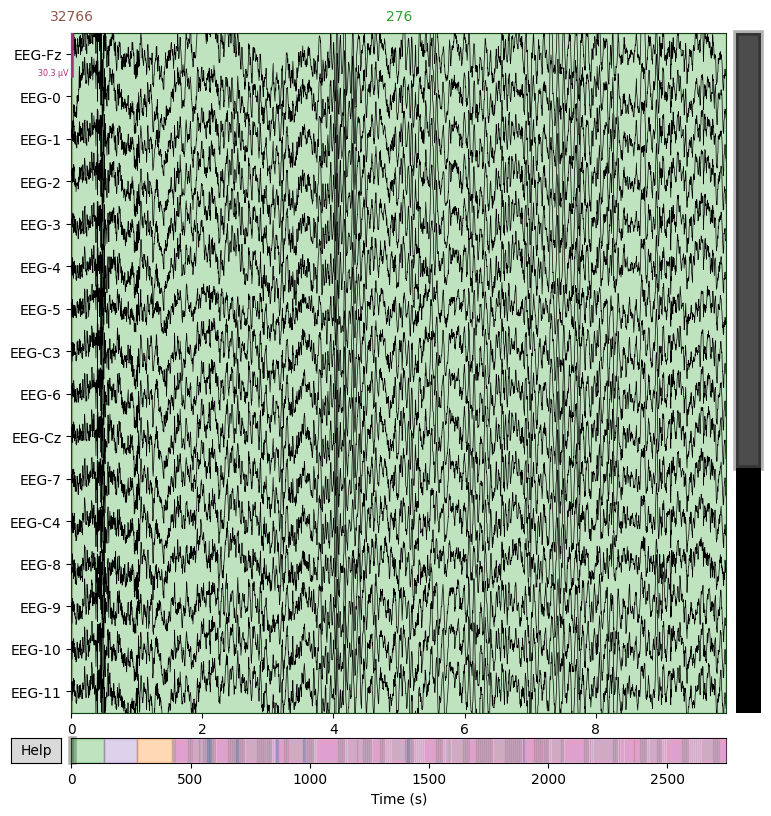

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '783']


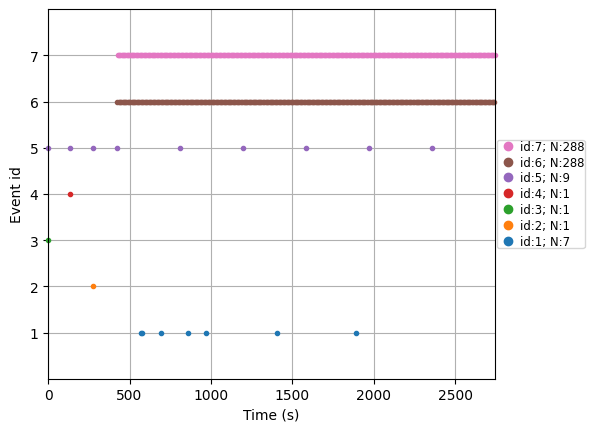

In [2]:
# Main execution
if __name__ == "__main__":
    dataset_path = r"C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV\dataset2"
    
    if os.path.exists(dataset_path):
        print(f"✅ Dataset ditemukan di: {dataset_path}")
        
        # 1. Quick check dulu
        quick_gdf_check(dataset_path)
        
        # 2. Analisis detail
        bci_competition_analysis(dataset_path)
        
        # 3. Tanya user apakah mau visualisasi
        response = input("\nApakah Anda ingin melihat visualisasi data? (y/n): ")
        if response.lower() == 'y':
            visualize_first_file(dataset_path)
            
    else:
        print(f"❌ Path tidak ditemukan: {dataset_path}")
        print("Cek struktur folder:")
        
        # Cek parent directory
        parent_dir = r"C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV"
        if os.path.exists(parent_dir):
            print(f"Files in parent directory: {os.listdir(parent_dir)}")

#Dataset EEGDenoiseNet
<p> berikut line untuk detail dataset dari EEG DenoiseNet

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

# Path dataset - FIXED: complete the string on one line
dataset_path = r"C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet"

def explore_dataset():
    print("=== EKSPLORASI DATASET EEGDenoiseNet ===\n")
    
    # Load data menggunakan .npy (lebih cepat)
    try:
        eeg_data = np.load(f"{dataset_path}/EEG_all_epochs.npy")
        eog_data = np.load(f"{dataset_path}/EOG_all_epochs.npy") 
        emg_data = np.load(f"{dataset_path}/EMG_all_epochs.npy")
        
        print("✅ Berhasil load semua file .npy")
        
    except:
        print("⚠️ Gagal load .npy, mencoba load .mat...")
        eeg_data = sio.loadmat(f"{dataset_path}/EEG_all_epochs.mat")['EEG_all_epochs']
        eog_data = sio.loadmat(f"{dataset_path}/EOG_all_epochs.mat")['EOG_all_epochs']
        emg_data = sio.loadmat(f"{dataset_path}/EMG_all_epochs.mat")['EMG_all_epochs']
        print("✅ Berhasil load semua file .mat")
    
    return eeg_data, eog_data, emg_data

# Load data
eeg_clean, eog_noise, emg_noise = explore_dataset()

# Analisis dimensi data
print(f"\n=== DIMENSI DATA ===")
print(f"EEG Clean Shape: {eeg_clean.shape}")
print(f"EOG Noise Shape: {eog_noise.shape}") 
print(f"EMG Noise Shape: {emg_noise.shape}")

# Analisis statistik dasar
print(f"\n=== STATISTIK DATA ===")
print(f"EEG - Min: {eeg_clean.min():.4f}, Max: {eeg_clean.max():.4f}, Mean: {eeg_clean.mean():.4f}")
print(f"EOG - Min: {eog_noise.min():.4f}, Max: {eog_noise.max():.4f}, Mean: {eog_noise.mean():.4f}")
print(f"EMG - Min: {emg_noise.min():.4f}, Max: {emg_noise.max():.4f}, Mean: {emg_noise.mean():.4f}")

=== EKSPLORASI DATASET EEGDenoiseNet ===

✅ Berhasil load semua file .npy

=== DIMENSI DATA ===
EEG Clean Shape: (4514, 512)
EOG Noise Shape: (3400, 512)
EMG Noise Shape: (5598, 512)

=== STATISTIK DATA ===
EEG - Min: -1684.6420, Max: 1798.9493, Mean: -0.0137
EOG - Min: -1226.9343, Max: 1182.9502, Mean: 0.0729
EMG - Min: -1304139.7926, Max: 1363045.1702, Mean: 56.5702


=== EKSPLORASI DATASET EEGDenoiseNet ===

✅ Berhasil load semua file .npy

=== DIMENSI DATA ===
EEG Clean Shape: (4514, 512)
EOG Noise Shape: (3400, 512)
EMG Noise Shape: (5598, 512)

=== STATISTIK DATA ===
EEG - Min: -1684.6420, Max: 1798.9493, Mean: -0.0137
EOG - Min: -1226.9343, Max: 1182.9502, Mean: 0.0729
EMG - Min: -1304139.7926, Max: 1363045.1702, Mean: 56.5702

=== GENERATING PLOTS ===


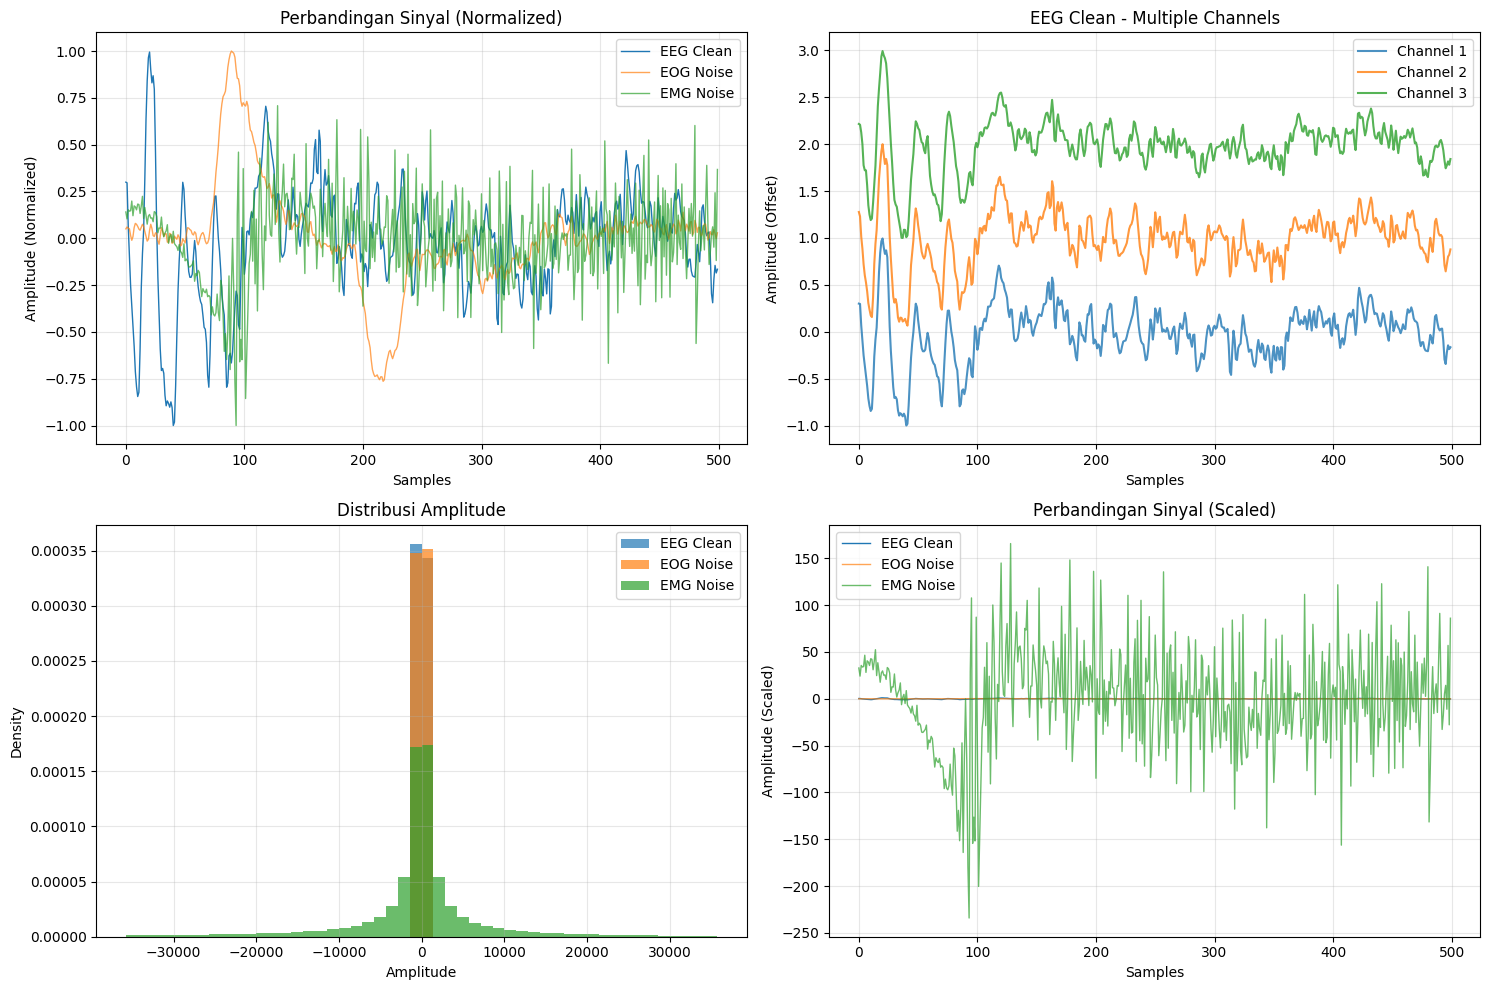


=== PLOTTING INDIVIDUAL SIGNALS ===


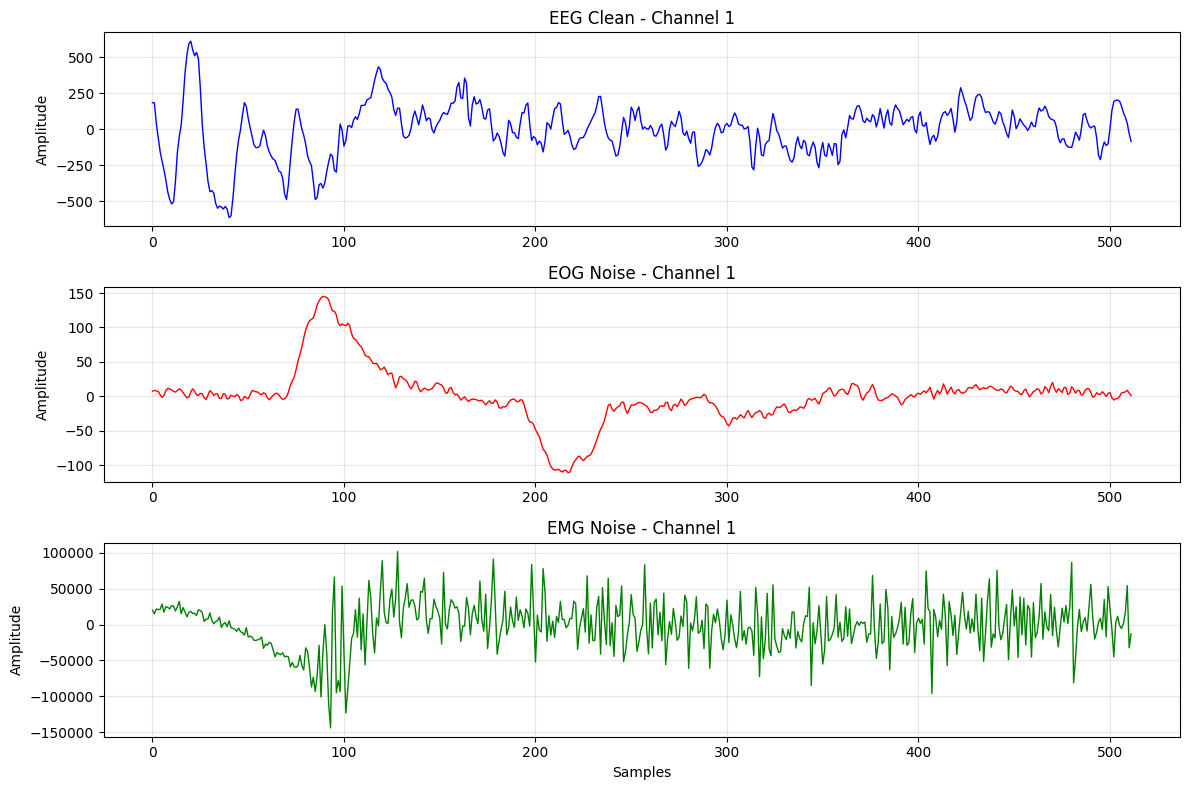

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import signal
import os

# Path dataset
dataset_path = r"C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet"

def explore_dataset():
    print("=== EKSPLORASI DATASET EEGDenoiseNet ===\n")
    
    # Load data menggunakan .npy (lebih cepat)
    try:
        eeg_data = np.load(f"{dataset_path}/EEG_all_epochs.npy")
        eog_data = np.load(f"{dataset_path}/EOG_all_epochs.npy") 
        emg_data = np.load(f"{dataset_path}/EMG_all_epochs.npy")
        
        print("✅ Berhasil load semua file .npy")
        
    except Exception as e:
        print(f"⚠️ Gagal load .npy: {e}, mencoba load .mat...")
        try:
            eeg_data = sio.loadmat(f"{dataset_path}/EEG_all_epochs.mat")['EEG_all_epochs']
            eog_data = sio.loadmat(f"{dataset_path}/EOG_all_epochs.mat")['EOG_all_epochs']
            emg_data = sio.loadmat(f"{dataset_path}/EMG_all_epochs.mat")['EMG_all_epochs']
            print("✅ Berhasil load semua file .mat")
        except Exception as e2:
            print(f"❌ Gagal load semua file: {e2}")
            return None, None, None
    
    return eeg_data, eog_data, emg_data

# Load data
eeg_clean, eog_noise, emg_noise = explore_dataset()

if eeg_clean is None:
    print("Tidak dapat melanjutkan karena data tidak terbaca")
else:
    # Analisis dimensi data
    print(f"\n=== DIMENSI DATA ===")
    print(f"EEG Clean Shape: {eeg_clean.shape}")  # (epochs, samples, channels) atau (channels, samples, epochs)
    print(f"EOG Noise Shape: {eog_noise.shape}") 
    print(f"EMG Noise Shape: {emg_noise.shape}")

    # Analisis statistik dasar
    print(f"\n=== STATISTIK DATA ===")
    print(f"EEG - Min: {eeg_clean.min():.4f}, Max: {eeg_clean.max():.4f}, Mean: {eeg_clean.mean():.4f}, Std: {eeg_clean.std():.4f}")
    print(f"EOG - Min: {eog_noise.min():.4f}, Max: {eog_noise.max():.4f}, Mean: {eog_noise.mean():.4f}, Std: {eog_noise.std():.4f}")
    print(f"EMG - Min: {emg_noise.min():.4f}, Max: {emg_noise.max():.4f}, Mean: {emg_noise.mean():.4f}, Std: {emg_noise.std():.4f}")

    # ========== ANALISIS FILTER ==========
    def analyze_filters():
        print(f"\n=== ANALISIS FILTER ===")
        
        # Contoh implementasi filter untuk EEG
        fs = 256  # Sampling frequency typical for EEG
        
        # Bandpass filter untuk EEG (0.5-45 Hz)
        nyquist = fs / 2
        lowcut, highcut = 0.5, 45
        b_eeg, a_eeg = signal.butter(4, [lowcut/nyquist, highcut/nyquist], btype='band')
        
        # Notch filter untuk powerline noise (50 Hz)
        notch_freq = 50
        quality_factor = 30
        b_notch, a_notch = signal.iirnotch(notch_freq, quality_factor, fs)
        
        print(f"✅ Bandpass Filter: {lowcut}-{highcut} Hz, Order: 4")
        print(f"✅ Notch Filter: {notch_freq} Hz, Q-factor: {quality_factor}")
        
        return b_eeg, a_eeg, b_notch, a_notch

    # ========== SEGMENTASI DATA ==========
    def analyze_segmentation(eeg_data, segment_length=256):
        print(f"\n=== ANALISIS SEGMENTASI ===")
        
        # Reshape data jika perlu
        if len(eeg_data.shape) == 3:
            n_epochs, n_samples, n_channels = eeg_data.shape
            total_segments = n_epochs * (n_samples // segment_length)
            print(f"Bentuk data 3D: {eeg_data.shape}")
            print(f"Panjang segment: {segment_length} samples")
            print(f"Total segments: {total_segments}")
            print(f"Durasi per segment: {segment_length/256:.2f} detik")
            
        elif len(eeg_data.shape) == 2:
            n_channels, n_samples = eeg_data.shape
            total_segments = n_samples // segment_length
            print(f"Bentuk data 2D: {eeg_data.shape}")
            print(f"Panjang segment: {segment_length} samples")
            print(f"Total segments: {total_segments}")
            print(f"Durasi per segment: {segment_length/256:.2f} detik")
            
        # Contoh segmentasi
        if len(eeg_data.shape) == 2 and eeg_data.shape[1] >= segment_length:
            segments = []
            for i in range(0, eeg_data.shape[1] - segment_length + 1, segment_length):
                segment = eeg_data[:, i:i+segment_length]
                segments.append(segment)
            print(f"✅ Berhasil membuat {len(segments)} segments")
            return segments
        else:
            print("⚠️ Tidak dapat melakukan segmentasi dengan bentuk data saat ini")
            return None

    # ========== DATA SEMI-SINTETIC ==========
    def create_synthetic_data(eeg_clean, eog_noise, emg_noise, snr_db=10):
        print(f"\n=== PEMBUATAN DATA SEMI-SINTETIC ===")
        
        # Pilih satu epoch/channel untuk contoh
        if len(eeg_clean.shape) == 3:
            eeg_example = eeg_clean[0, :, 0]  # epoch pertama, semua samples, channel pertama
            eog_example = eog_noise[0, :, 0]
            emg_example = emg_noise[0, :, 0]
        else:
            eeg_example = eeg_clean[0, :]  # channel pertama, semua samples
            eog_example = eog_noise[0, :]
            emg_example = emg_noise[0, :]
        
        # Normalisasi noise
        eog_normalized = eog_example / np.std(eog_example)
        emg_normalized = emg_example / np.std(emg_example)
        
        # Hitung power signal dan noise
        eeg_power = np.mean(eeg_example ** 2)
        target_noise_power = eeg_power / (10 ** (snr_db / 10))
        
        # Scale noise untuk mencapai SNR yang diinginkan
        eog_scaled = eog_normalized * np.sqrt(target_noise_power)
        emg_scaled = emg_normalized * np.sqrt(target_noise_power)
        
        # Buat data noisy
        eeg_eog_noisy = eeg_example + eog_scaled
        eeg_emg_noisy = eeg_example + emg_scaled
        eeg_both_noisy = eeg_example + eog_scaled + emg_scaled
        
        print(f"✅ SNR target: {snr_db} dB")
        print(f"✅ Created: EEG+EOG noisy, EEG+EMG noisy, EEG+EOG+EMG noisy")
        
        return eeg_example, eog_scaled, emg_scaled, eeg_eog_noisy, eeg_emg_noisy, eeg_both_noisy

    # ========== VISUALISASI LENGKAP ==========
    def plot_comprehensive_analysis(eeg_clean, eog_noise, emg_noise):
        plt.figure(figsize=(18, 12))
        
        # Buat data semi-sintetic
        eeg_clean_ex, eog_scaled, emg_scaled, eeg_eog_noisy, eeg_emg_noisy, eeg_both_noisy = create_synthetic_data(
            eeg_clean, eog_noise, emg_noise, snr_db=10
        )
        
        n_samples = min(1000, len(eeg_clean_ex))
        
        # 1. Original vs Noisy Signals
        plt.subplot(3, 3, 1)
        plt.plot(eeg_clean_ex[:n_samples], 'b-', label='EEG Clean', linewidth=1)
        plt.plot(eeg_eog_noisy[:n_samples], 'r-', label='EEG+EOG', linewidth=1, alpha=0.7)
        plt.title('EEG Clean vs EEG+EOG Noisy')
        plt.xlabel('Samples')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 2)
        plt.plot(eeg_clean_ex[:n_samples], 'b-', label='EEG Clean', linewidth=1)
        plt.plot(eeg_emg_noisy[:n_samples], 'g-', label='EEG+EMG', linewidth=1, alpha=0.7)
        plt.title('EEG Clean vs EEG+EMG Noisy')
        plt.xlabel('Samples')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 3)
        plt.plot(eeg_clean_ex[:n_samples], 'b-', label='EEG Clean', linewidth=1)
        plt.plot(eeg_both_noisy[:n_samples], 'purple', label='EEG+EOG+EMG', linewidth=1, alpha=0.7)
        plt.title('EEG Clean vs All Noisy')
        plt.xlabel('Samples')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 2. Frequency Analysis
        plt.subplot(3, 3, 4)
        f_clean, Pxx_clean = signal.welch(eeg_clean_ex, fs=256, nperseg=512)
        f_eog, Pxx_eog = signal.welch(eeg_eog_noisy, fs=256, nperseg=512)
        
        plt.semilogy(f_clean, Pxx_clean, 'b-', label='EEG Clean')
        plt.semilogy(f_eog, Pxx_eog, 'r-', label='EEG+EOG', alpha=0.7)
        plt.title('Power Spectral Density')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel('PSD')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 60)
        
        # 3. Noise Components
        plt.subplot(3, 3, 5)
        plt.plot(eog_scaled[:n_samples], 'r-', label='EOG Noise', linewidth=1)
        plt.plot(emg_scaled[:n_samples], 'g-', label='EMG Noise', linewidth=1)
        plt.title('Noise Components (Scaled)')
        plt.xlabel('Samples')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 4. Segmentasi Example
        plt.subplot(3, 3, 6)
        segment_length = 256
        if len(eeg_clean_ex) >= segment_length * 3:
            for i in range(3):
                start_idx = i * segment_length
                end_idx = (i + 1) * segment_length
                segment = eeg_clean_ex[start_idx:end_idx]
                plt.plot(np.arange(start_idx, end_idx), segment, label=f'Segment {i+1}')
            plt.title('Contoh Segmentasi Data')
            plt.xlabel('Samples')
            plt.ylabel('Amplitude')
            plt.legend()
            plt.grid(True, alpha=0.3)
        
        # 7. Histogram Comparison
        plt.subplot(3, 3, 7)
        plt.hist(eeg_clean_ex, bins=50, alpha=0.7, label='EEG Clean', density=True)
        plt.hist(eeg_eog_noisy, bins=50, alpha=0.7, label='EEG+EOG', density=True)
        plt.hist(eeg_emg_noisy, bins=50, alpha=0.7, label='EEG+EMG', density=True)
        plt.title('Distribusi Amplitude')
        plt.xlabel('Amplitude')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 8. Correlation Analysis
        plt.subplot(3, 3, 8)
        lags = np.arange(-50, 51)
        cross_corr = np.correlate(eeg_clean_ex[:500], eog_scaled[:500], mode='full')
        valid_lags = lags
        plt.plot(valid_lags, cross_corr[475:576], 'r-')
        plt.title('Cross-Correlation EEG-EOG')
        plt.xlabel('Lag')
        plt.ylabel('Correlation')
        plt.grid(True, alpha=0.3)
        
        # 9. Filter Response
        plt.subplot(3, 3, 9)
        b_eeg, a_eeg, b_notch, a_notch = analyze_filters()
        
        w_eeg, h_eeg = signal.freqz(b_eeg, a_eeg, fs=256)
        w_notch, h_notch = signal.freqz(b_notch, a_notch, fs=256)
        
        plt.plot(w_eeg, 20 * np.log10(abs(h_eeg)), 'b-', label='Bandpass (0.5-45 Hz)')
        plt.plot(w_notch, 20 * np.log10(abs(h_notch)), 'r-', label='Notch (50 Hz)')
        plt.title('Filter Responses')
        plt.xlabel('Frequency [Hz]')
        plt.ylabel('Magnitude [dB]')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 60)
        
        plt.tight_layout()
        plt.show()

    # Run semua analisis
    print(f"\n=== MENJALANKAN ANALISIS LENGKAP ===")
    
    # Analisis filter
    analyze_filters()
    
    # Analisis segmentasi
    segments = analyze_segmentation(eeg_clean)
    
    # Buat data semi-sintetic
    synthetic_data = create_synthetic_data(eeg_clean, eog_noise, emg_noise)
    
    # Plot comprehensive
    plot_comprehensive_analysis(eeg_clean, eog_noise, emg_noise)

    # Additional: Info tentang dataset
    print(f"\n=== INFORMASI DATASET ===")
    print(f"Dataset path: {dataset_path}")
    print(f"File yang tersedia:")
    for file in ['EEG_all_epochs.npy', 'EOG_all_epochs.npy', 'EMG_all_epochs.npy',
                 'EEG_all_epochs.mat', 'EOG_all_epochs.mat', 'EMG_all_epochs.mat']:
        file_path = os.path.join(dataset_path, file)
        if os.path.exists(file_path):
            file_size = os.path.getsize(file_path) / (1024*1024)  # MB
            print(f"  ✅ {file}: {file_size:.2f} MB")
        else:
            print(f"  ❌ {file}: Tidak ditemukan")